# Predator-prey Model Under the Lotka-Volterra (LV) System.

## Model Overview 

This notebook simulates predator-prey dynamics using the Lotka-Volterra (LV) equations. It demonstrates how populations interact over time and how parameter changes influence the system behavior.

## The Conceptual Framework

Two populations interact: prey (N) reproduces, predators (P) consume prey and experience mortality.

## Mathematical Formulation

The Lotka-Volterra equation describes the temporal dynamics of the system:

**dN/dt =  rN - aNP**

**dP/dt =bNP - mP**

## Parameters Definition

- **N:** prey population
- **P**: predator population
- **r:** intrinsic growth rate of prey
- **a:** predation rate coefficient
- **b:** conversion efficiency of consumed prey into predator reproduction
- **m:** predator mortality rate

In [13]:
# Simulation setup 

import numpy as np  
import matplotlib.pyplot as plt  
from scipy.integrate import odeint #Numerical ODE solver

In [15]:
### Parameters Initialization 

# Initial conditions: population sizes at time t= 0
N0 = 40  # prey
P0 = 9   # predator

# Parameters
r = 0.1  # prey growth rate
a = 0.02 # predation rate
b = 0.01 # predator conversion efficiency
m = 0.1  # predator mortality rate

# Time vector
t = np.linspace(0, 200, 1000)  # discrete time grid

In [17]:
### ODE Function: the LV eqn  

def lotka_volterra(y, t, r, a, b, m):
    """
    y: state vector [N, P] 
    t: time variable
    
    """
    N, P = y    # unpacks current population values
    dNdt = r*N - a*N*P   # rate of change of prey population 
    dPdt = b*N*P - m*P    #rate of change of predatoe population 
    return [dNdt, dPdt]

In [19]:
# Initial state vector @ t= 0
y0 = [N0, P0]

# Integrate ODEs over time 
solution = odeint(lotka_volterra, y0, t, args=(r, a, b, m))
N, P = solution.T

## Visualization 

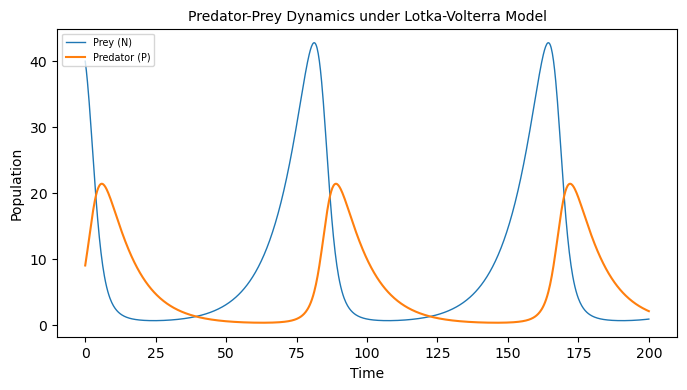

In [46]:
plt.figure(figsize=(8,4))
plt.plot(t, N, linewidth=1, label='Prey (N)')
plt.plot(t, P, label='Predator (P)')
plt.xlabel('Time', fontsize=10)
plt.ylabel('Population', fontsize=10)
plt.title('Predator-Prey Dynamics under Lotka-Volterra Model', fontsize= 10)
plt.legend(loc=2, fontsize= 'x-small')
plt.savefig('plot.png')
plt.show()

Time series showing osilations in prey and predator populations. peaks and troughs reflect population cycles.

## Parameter Exploration